# Lab 5: Gaussian Mixture Model - Mall Customer Segmentation

In [1]:
RAND_SEED = 42

## 1. EDA

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
int_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
for c in int_cols:
    print(f"Column: {c}")
    print(df[c].describe())
    print()

Column: Age
count    200.000000
mean      38.850000
std       13.969007
min       18.000000
25%       28.750000
50%       36.000000
75%       49.000000
max       70.000000
Name: Age, dtype: float64

Column: Annual Income (k$)
count    200.000000
mean      60.560000
std       26.264721
min       15.000000
25%       41.500000
50%       61.500000
75%       78.000000
max      137.000000
Name: Annual Income (k$), dtype: float64

Column: Spending Score (1-100)
count    200.000000
mean      50.200000
std       25.823522
min        1.000000
25%       34.750000
50%       50.000000
75%       73.000000
max       99.000000
Name: Spending Score (1-100), dtype: float64



In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# rename columns
df = df.rename(columns={
    "CustomerID": "id",
    "Gender": "gender",
    "Age": "age",
    "Annual Income (k$)": "aIncome",
    "Spending Score (1-100)": "sScore"
})

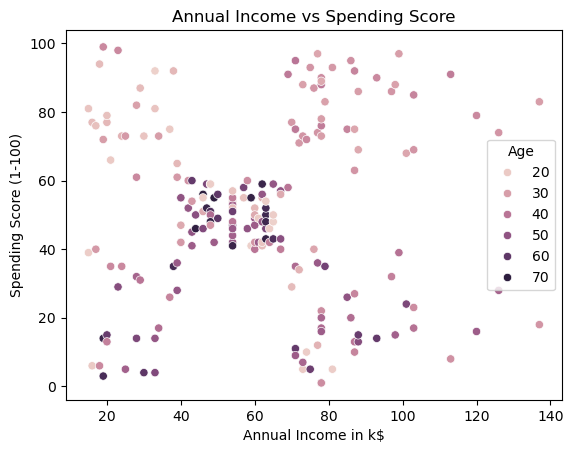

In [7]:
sns.scatterplot(data=df, x="aIncome", y="sScore", hue="age")
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income in k$")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Age")
plt.show()

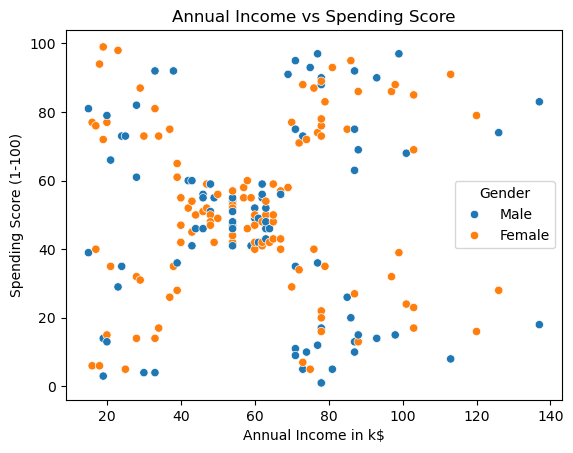

In [8]:
sns.scatterplot(data=df, x="aIncome", y="sScore", hue="gender")
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income in k$")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Gender")
plt.show()

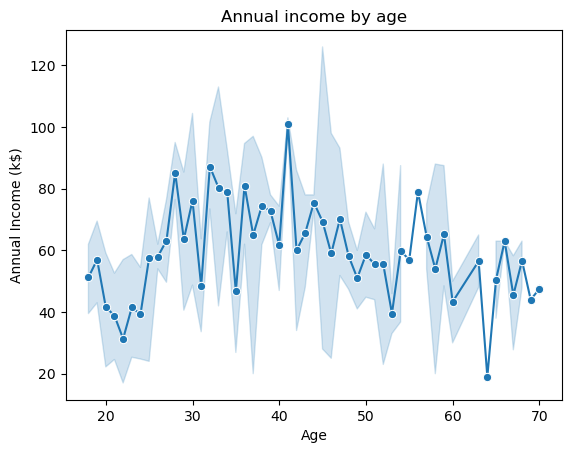

In [9]:
sns.lineplot(data=df, x="age", y="aIncome", marker="o")
plt.title("Annual income by age")
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.show()

In [10]:
import plotly.express as px

px.scatter(df, x="age", y="aIncome")

### Дүгнэлт:

- 40-өөс дээш насны хүмүүсийн мөнгө үрэх оноо нь 60-аас хэтрэхгүй байхад 40-өөс залуу хүмүүсийнх 40-100 хооронд байна
- Жилийн дундаж орлого нь 100K$-оос дээш ба 30-40 насны хүмүүсийн мөнгө үрэх оноо өндөр байгаа харагдаж байна
- Жилийн дундаж орлого болон мөнгө үрэх оноогоороо хүмүүс ерөнхийдөө 5 бүлэгт хуваагдаж байгаа харагдаж байна
- Ихэнх хүмүүсийн жилийн дундаж орлого 40-80k$ байхад мөнгө үрэх оноо нь 40-60 хооронд байгаа харагдаж байна
- Эрэгтэйчүүд дунджаар илүү мөнгө олдог байхад эмэгтэйчүүд илүү мөнгө үрэх оноотой байна
- Жилд дунджаар +120k$ олдог цөөхөн outliers харагдаж байна

In [11]:
df_enc = pd.get_dummies(df, columns=["gender"], drop_first=True)
df_enc

,id,age,aIncome,sScore,gender_Male
0,1,19,15,39,True
1,2,21,15,81,True
2,3,20,16,6,False
3,4,23,16,77,False
4,5,31,17,40,False
...,...,...,...,...,...
195,196,35,120,79,False
196,197,45,126,28,False
197,198,32,126,74,True
198,199,32,137,18,True


## 2. Select Number of components

### 1. Scale features

In [12]:
features = ["aIncome", "sScore"]

In [13]:
from sklearn.preprocessing import StandardScaler
import numpy as np

Feature-үүдээр "Annual Income", "Spending Score", "Age" шинж чанаруудыг сонголоо.

In [14]:
dff = df[features]
dff

,aIncome,sScore
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [15]:
scaler = StandardScaler()
scaler.fit(dff)
X = scaler.transform(dff)
print(X[:5])
print("...")

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]
...


### 2. Test BIC score

In [16]:
from sklearn.mixture import GaussianMixture

In [17]:
n_comps = range(1, 11)
bic_scores = []
log_scores = []

for n in n_comps:
    gmm = GaussianMixture(n_components=n, random_state=RAND_SEED)
    gmm.fit(X)
    bic = gmm.bic(X)
    score = gmm.score(X)
    bic_scores.append(bic)
    log_scores.append(score)

c:\Users\Nitro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\Nitro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\Nitro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\Nitro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than 

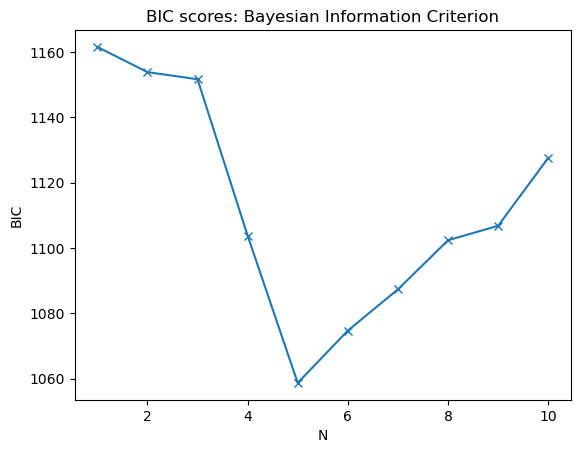

In [18]:
plt.plot(range(1, 11), bic_scores, marker="x")
plt.title("BIC scores: Bayesian Information Criterion")
plt.xlabel("N")
plt.ylabel("BIC")
plt.show()

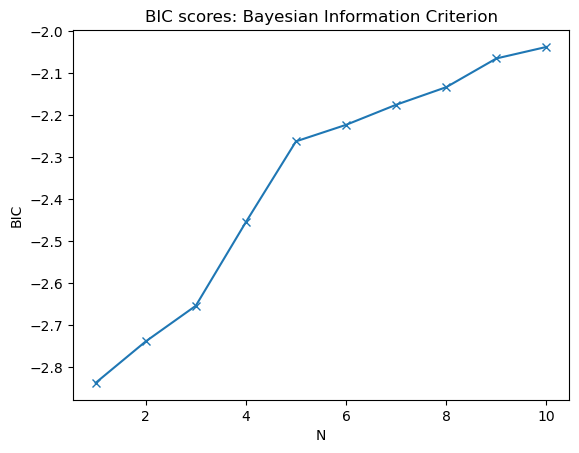

In [19]:
plt.plot(range(1, 11), log_scores, marker="x")
plt.title("BIC scores: Bayesian Information Criterion")
plt.xlabel("N")
plt.ylabel("BIC")
plt.show()

#### Дүгнэлт:

- N тоо 5 байх үед BIC оноо хамгийн бага байна

## 3. GMM

In [20]:
gm = GaussianMixture(n_components=5, n_init=10, max_iter=100, random_state=RAND_SEED)

In [21]:
gm.fit(X)

c:\Users\Nitro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\Nitro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\Nitro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\Nitro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than 

GaussianMixture(n_components=5, n_init=10, random_state=42)

In [22]:
centroids = gm.means_
print(centroids)

[[-0.18510822 -0.030786  ]
 [ 0.98021511  1.23531662]
 [-1.35282052  1.16185843]
 [ 1.07840119 -1.3228595 ]
 [-1.27977698 -1.0882964 ]]


In [23]:
labels = gm.predict(X)
print(labels[:5])

[4 2 4 2 4]


In [24]:
probs = gm.predict_proba(X)
print(probs[:5])

[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


In [25]:
df_scaled_pd = pd.DataFrame(X, columns=features)
df_scaled_pd

,aIncome,sScore
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980
...,...,...
195,2.268791,1.118061
196,2.497807,-0.861839
197,2.497807,0.923953
198,2.917671,-1.250054


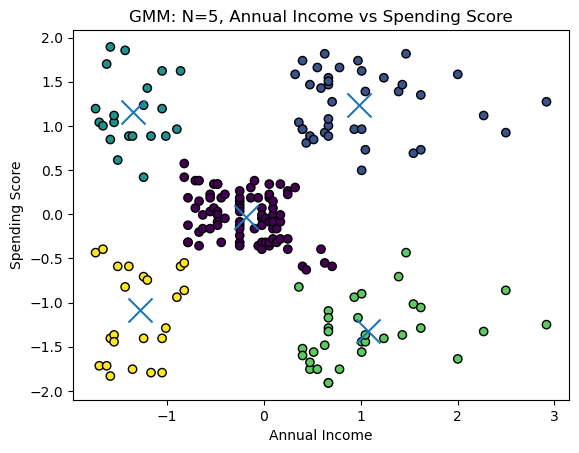

In [26]:
x1 = df_scaled_pd.loc[:, "aIncome"]
x2 = df_scaled_pd.loc[:, "sScore"]

# plt.scatter(df_scaled.iloc[:, 0], df_scaled.iloc[:, 1], marker="o")
plt.scatter(x1, x2, marker="o", c=labels, edgecolor="k")
plt.scatter(centroids[:, 0], centroids[:, 1], marker="x", s=300, label="Centroids")
plt.title("GMM: N=5, Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

In [27]:
centroids_unscaled = scaler.inverse_transform(centroids)

for c in centroids_unscaled:
    print(f"Annual Income (k$): \t\t {round(c[0], 2)}")
    print(f"Spending Score (1-100):\t\t {round(c[1], 1)}")
    print()

Annual Income (k$): 		 55.71
Spending Score (1-100):		 49.4

Annual Income (k$): 		 86.24
Spending Score (1-100):		 82.0

Annual Income (k$): 		 25.12
Spending Score (1-100):		 80.1

Annual Income (k$): 		 88.81
Spending Score (1-100):		 16.1

Annual Income (k$): 		 27.03
Spending Score (1-100):		 22.2

